<a href="https://colab.research.google.com/github/Kyle440/option-pricer/blob/main/option_pricer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fair-Value-Rechner für Optionen

Kleines Projekt zur Bewerbung als Trading Trainee bei der Börse Stuttgart / EUWAX AG.

Berechnet den theoretischen Fair Value von Optionen mit dem Black-Scholes-Modell
und vergleicht diesen mit echten Marktpreisen (Apple-Aktienoptionen, via yfinance).

**Autor:** Kyle Zieher, [Link zu deiner Bewerbungs-Website]  

In [ ]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Wählen einer sehr liquiden Aktie mit guter Datenverfügbarkeit
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# Historische Tageskurse der letzten 6 Monate laden
history = ticker.history(period="6mo")
print(history.tail())

                                 Open        High         Low       Close  \
Date                                                                        
2026-08-31 00:00:00-04:00  319.600006  321.239990  312.799988  316.850006   
2026-09-01 00:00:00-04:00  316.980011  327.299988  314.730011  325.130005   
2026-09-02 00:00:00-04:00  326.869995  328.399994  323.529999  324.959991   
2026-09-03 00:00:00-04:00  324.869995  330.809998  324.109985  328.209991   
2026-09-04 00:00:00-04:00  328.309998  328.929993  317.859985  319.970001   

                             Volume  Dividends  Stock Splits  
Date                                                          
2026-08-31 00:00:00-04:00  41242700        0.0           0.0  
2026-09-01 00:00:00-04:00  53167400        0.0           0.0  
2026-09-02 00:00:00-04:00  33776400        0.0           0.0  
2026-09-03 00:00:00-04:00  37225800        0.0           0.0  
2026-09-04 00:00:00-04:00  39551800        0.0           0.0  


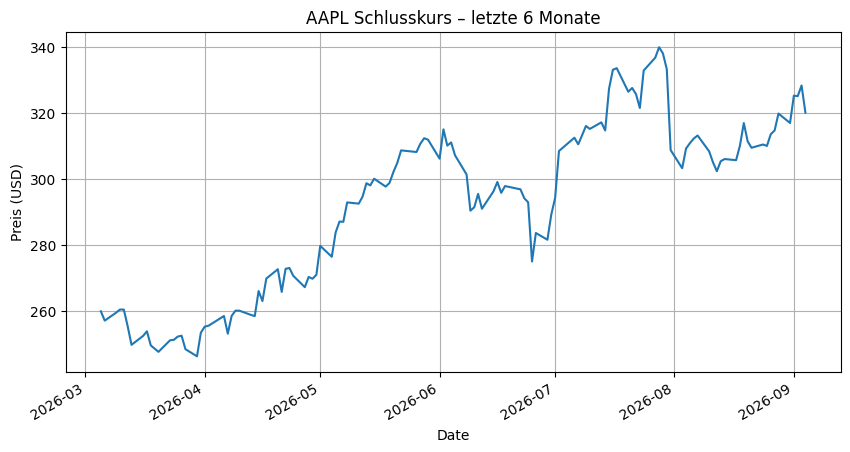

In [ ]:
history['Close'].plot(figsize=(10, 5), title=f"{ticker_symbol} Schlusskurs – letzte 6 Monate")
plt.ylabel("Preis (USD)")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm

def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    """
    Berechnet den theoretischen Fair Value einer Option nach dem Black-Scholes-Modell.

    S: Aktueller Kurs des Basiswerts
    K: Strike-Preis
    T: Restlaufzeit in Jahren (z.B. 0.5 = 6 Monate)
    r: Risikoloser Zinssatz (z.B. 0.04 = 4%)
    sigma: Volatilität (z.B. 0.25 = 25%)
    option_type: "call" oder "put"
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type muss 'call' oder 'put' sein")

    return price

In [ ]:
# Testrechnung mit Beispielwerten
test_price = black_scholes_price(
    S=150,      # Aktueller Kurs = 150 USD
    K=155,      # Strike: 155 USD
    T=0.5,      # Restlaufzeit: 6 Monate
    r=0.04,     # Risikoloser Zins: 4%
    sigma=0.25, # Volatilität: 25%
    option_type="call"
)
print(f"Theoretischer Fair Value (Call): {test_price:.2f} USD")

Theoretischer Fair Value (Call): 9.70 USD


In [ ]:
# Tägliche Log-Renditen berechnen
history['log_return'] = np.log(history['Close'] / history['Close'].shift(1))

# Standardabweichung der täglichen Renditen, annualisiert
daily_vol = history['log_return'].std()
annual_vol = daily_vol * np.sqrt(252)

print(f"Tägliche Volatilität: {daily_vol:.4f}")
print(f"Annualisierte historische Volatilität: {annual_vol:.4f} ({annual_vol*100:.1f}%)")

Tägliche Volatilität: 0.0173
Annualisierte historische Volatilität: 0.2751 (27.5%)


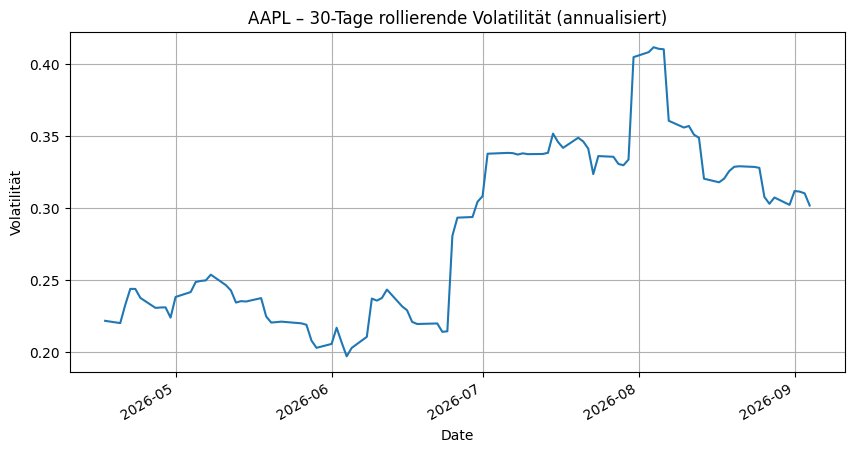

In [ ]:
history['rolling_vol_30d'] = history['log_return'].rolling(window=30).std() * np.sqrt(252)

history['rolling_vol_30d'].plot(figsize=(10, 5), title=f"{ticker_symbol} – 30-Tage rollierende Volatilität (annualisiert)")
plt.ylabel("Volatilität")
plt.grid(True)
plt.show()

In [ ]:
# Alle verfügbaren Verfallstermine für Apple-Optionen anzeigen
expirations = ticker.options
print(expirations)

('2026-09-09', '2026-09-11', '2026-09-14', '2026-09-16', '2026-09-18', '2026-09-25', '2026-10-02', '2026-10-09', '2026-10-16', '2026-10-23', '2026-11-20', '2026-12-18', '2027-01-15', '2027-02-19', '2027-03-19', '2027-04-16', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


In [ ]:
chosen_expiration = expirations[10]
print(f"Gewählter Verfallstermin: {chosen_expiration}")

option_chain = ticker.option_chain(chosen_expiration)
calls = option_chain.calls
print(calls[['strike', 'lastPrice', 'bid', 'ask', 'impliedVolatility']].head(10))

Gewählter Verfallstermin: 2026-11-20
   strike  lastPrice     bid     ask  impliedVolatility
0   100.0     217.92    0.00    0.00           0.000010
1   105.0     158.60  161.75  164.75           0.000010
2   110.0     190.16  210.85  214.65           1.480471
3   115.0     173.82  186.90  190.55           0.000010
4   120.0     206.14    0.00    0.00           0.000010
5   125.0     202.96    0.00    0.00           0.000010
6   130.0     197.93    0.00    0.00           0.000010
7   135.0     181.23    0.00    0.00           0.000010
8   140.0     187.34    0.00    0.00           0.000010
9   145.0     171.02    0.00    0.00           0.000010


In [ ]:
from datetime import datetime

# Restlaufzeit in Jahren
today = datetime.now()
expiration_date = datetime.strptime(chosen_expiration, "%Y-%m-%d")
T = (expiration_date - today).days / 365

# Aktueller Aktienkurs (letzter verfügbarer Schlusskurs)
S = history['Close'].iloc[-1]

r = 0.04       # vereinfachte Annahme: risikoloser Zins ~4%
sigma = annual_vol

print(f"S={S:.2f} USD | K variiert | T={T:.4f} Jahre | r={r} | sigma={sigma:.4f}")

S=319.97 USD | K variiert | T=0.1973 Jahre | r=0.04 | sigma=0.2751


In [ ]:
# Alle Strikes nahe am aktuellen Kurs (ohne strengen bid>0 Filter)
calls_near_money = calls[(calls['strike'] > S * 0.8) & (calls['strike'] < S * 1.2)].copy()

def get_market_price(row):
    if row['bid'] > 0 and row['ask'] > 0:
        return pd.Series([(row['bid'] + row['ask']) / 2, "bid/ask-Mitte"])
    elif row['lastPrice'] > 0:
        return pd.Series([row['lastPrice'], "lastPrice (Fallback)"])
    else:
        return pd.Series([np.nan, "keine Daten"])

calls_near_money[['market_price', 'price_source']] = calls_near_money.apply(get_market_price, axis=1)

calls_near_money['theoretical_price'] = calls_near_money['strike'].apply(
    lambda K: black_scholes_price(S=S, K=K, T=T, r=r, sigma=sigma, option_type="call")
)
calls_near_money['diff'] = calls_near_money['theoretical_price'] - calls_near_money['market_price']

comparison = calls_near_money.dropna(subset=['market_price'])[
    ['strike', 'market_price', 'price_source', 'theoretical_price', 'diff', 'impliedVolatility']
]
print(comparison.to_string(index=False))

 strike  market_price         price_source  theoretical_price      diff  impliedVolatility
  260.0         63.95 lastPrice (Fallback)          62.561622 -1.388378           0.000010
  265.0         59.30 lastPrice (Fallback)          57.860572 -1.439428           0.000010
  270.0         54.70 lastPrice (Fallback)          53.252127 -1.447873           0.000010
  275.0         50.70 lastPrice (Fallback)          48.757405 -1.942595           0.000010
  280.0         46.11 lastPrice (Fallback)          44.398697 -1.711303           0.000010
  285.0         42.25 lastPrice (Fallback)          40.198643 -2.051357           0.000010
  290.0         37.00 lastPrice (Fallback)          36.179297 -0.820703           0.000010
  295.0         34.25 lastPrice (Fallback)          32.361176 -1.888824           0.000010
  300.0         29.75 lastPrice (Fallback)          28.762360 -0.987640           0.000010
  305.0         27.50 lastPrice (Fallback)          25.397713 -2.102287           0.000010

In [ ]:
# Aktuellster verfügbarer Kurs (statt letzter Tagesschluss)
fast_info = ticker.fast_info
S = fast_info['last_price']
print(f"Aktualisierter Kurs S = {S:.2f} USD")

Aktualisierter Kurs S = 319.97 USD


Limit kostenloser Datenquellen. Live-Daten würden einen kostenpflichtigen Feed erfordern, für dieses Modell wurde mit dem letzten verfügbaren Schlusskurs gearbeitet.

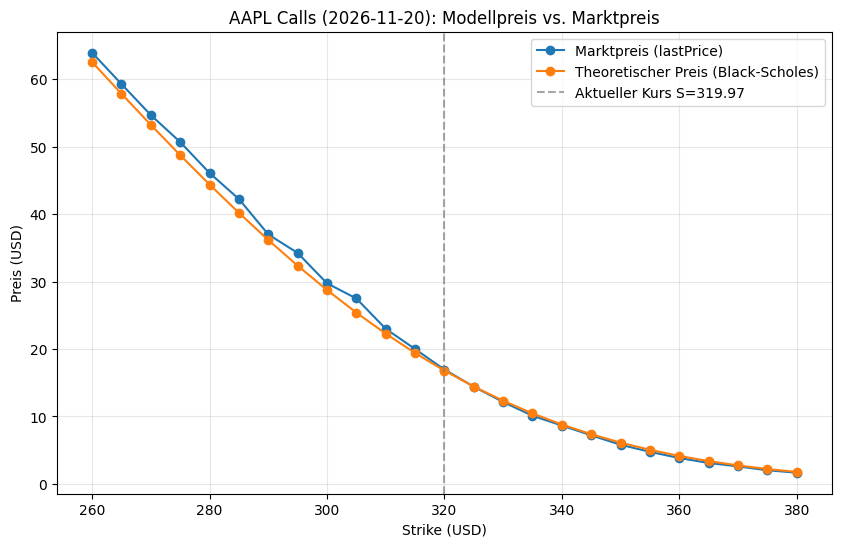

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(comparison['strike'], comparison['market_price'], marker='o', label='Marktpreis (lastPrice)')
plt.plot(comparison['strike'], comparison['theoretical_price'], marker='o', label='Theoretischer Preis (Black-Scholes)')
plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Aktueller Kurs S={S:.2f}')
plt.xlabel('Strike (USD)')
plt.ylabel('Preis (USD)')
plt.title(f'{ticker_symbol} Calls ({chosen_expiration}): Modellpreis vs. Marktpreis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

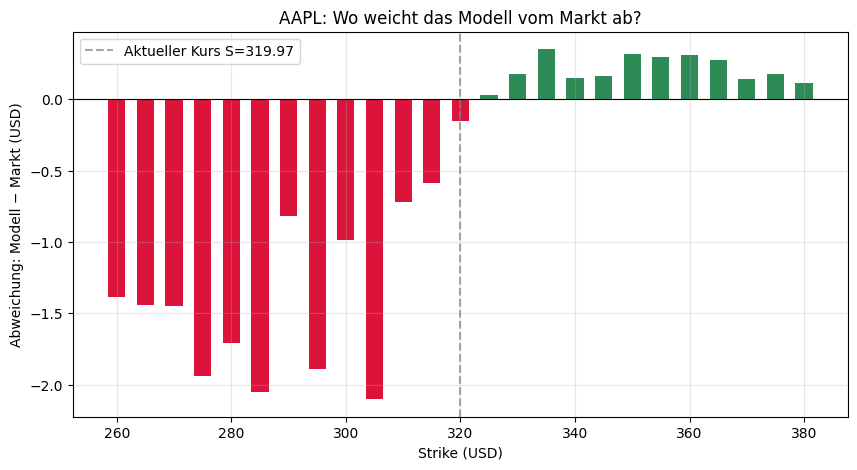

In [ ]:
plt.figure(figsize=(10, 5))
colors = ['crimson' if x < 0 else 'seagreen' for x in comparison['diff']]
plt.bar(comparison['strike'], comparison['diff'], color=colors, width=3)
plt.axhline(y=0, color='black', linewidth=0.8)
plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Aktueller Kurs S={S:.2f}')
plt.xlabel('Strike (USD)')
plt.ylabel('Abweichung: Modell − Markt (USD)')
plt.title(f'{ticker_symbol}: Wo weicht das Modell vom Markt ab?')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Mit diesem Fair-Value-Modell für Optionen wollte ich mithilfe der Black-Scholes-Formel und Daten von yfinance den fairen Wert einer Option berechnen, also herausfinden, ob eine Option gerade über- oder unterbewertet ist.

Dafür habe ich zuerst historische Kursdaten der Apple-Aktie geladen und daraus die Volatilität berechnet (rund 27,5% pro Jahr). Diese Volatilität und der aktuelle Aktienkurs waren dann die wichtigsten Inputs für mein Black-Scholes-Modell. Damit habe ich für verschiedene Call-Optionen (Verfall im November 2026) den theoretischen Preis berechnet und mit den echten Marktpreisen verglichen.

Das Ergebnis: Bei Optionen nahe am aktuellen Aktienkurs lag mein Modell sehr nah am Marktpreis, die Abweichung war oft unter 20 Cent. Bei Optionen, die tief im Geld waren, wurde die Abweichung deutlich größer, bis zu etwa 2 USD. Beim genaueren Hinschauen ist mir aufgefallen, dass die implizite Volatilität in den Marktdaten für diese Optionen unrealistisch niedrig war. Das hat mich stutzig gemacht und darauf schließen lassen, dass es sich nicht um einen echten Markteffekt handelt, sondern eher daran liegt, dass die verwendeten Marktpreise über den kostenlosen Datenfeed nicht ganz aktuell waren, sondern vom letzten tatsächlichen Trade stammten.

Ich ziehe daraus folgendes Fazit: Ein Modell ist nur so gut wie die Daten, die man reinsteckt, und man sollte Ergebnisse immer kritisch hinterfragen statt sie einfach zu glauben. Mit einem Live Datenfeed und einer variablen Volatilität pro Strike ließe sich das Modell in einem nächsten Schritt noch genauer machen.